In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Original Dataset
x1 = np.array([2.5, 0.5, 2.2, 1.9, 3.1, 2.3, 2.0, 1.0, 1.5, 1.1])
x2 = np.array([2.4, 0.7, 2.9, 2.2, 3.0, 2.7, 1.6, 1.1, 1.6, 0.9])
X = np.vstack((x1, x2)).T
print("Original Dataset:")
df=pd.DataFrame(X, columns=['x1', 'x2'])
print(pd.DataFrame(X, columns=['x1', 'x2']))
df.to_csv("pca.csv", index=False)

Original Dataset:
    x1   x2
0  2.5  2.4
1  0.5  0.7
2  2.2  2.9
3  1.9  2.2
4  3.1  3.0
5  2.3  2.7
6  2.0  1.6
7  1.0  1.1
8  1.5  1.6
9  1.1  0.9


In [ ]:
# PCA Calculation
mean = np.mean(X, axis=0)
X_centered = X - mean
cov_matrix = np.cov(X_centered, rowvar=False)

# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
V = eigenvectors[:, sorted_indices]

print("PCA Results:")
print(f"Mean: {mean.round(4)}")
print(f"Covariance Matrix:\n{cov_matrix.round(6)}")
print(f"Eigenvalue 1: {eigenvalues[0]:.6f}")
print(f"Eigenvalue 2: {eigenvalues[1]:.6f}")
print(f"Eigenvectors:\n{V.round(6)}")

PCA Results:
Mean: [1.81 1.91]
Covariance Matrix:
[[0.616556 0.615444]
 [0.615444 0.716556]]
Eigenvalue 1: 1.284028
Eigenvalue 2: 0.049083
Eigenvectors:
[[-0.677873 -0.735179]
 [-0.735179  0.677873]]


In [ ]:
# Full Reconstruction with all components
Z = X_centered @ V
X_reconstructed_full = Z @ V.T + mean

print("Full Reconstruction:")
print(pd.DataFrame({
    'Original x1': X[:, 0],
    'Reconstructed x1': X_reconstructed_full[:, 0],
    'Original x2': X[:, 1],
    'Reconstructed x2': X_reconstructed_full[:, 1]
}).round(4))

Full Reconstruction:
   Original x1  Reconstructed x1  Original x2  Reconstructed x2
0          2.5               2.5          2.4               2.4
1          0.5               0.5          0.7               0.7
2          2.2               2.2          2.9               2.9
3          1.9               1.9          2.2               2.2
4          3.1               3.1          3.0               3.0
5          2.3               2.3          2.7               2.7
6          2.0               2.0          1.6               1.6
7          1.0               1.0          1.1               1.1
8          1.5               1.5          1.6               1.6
9          1.1               1.1          0.9               0.9


In [ ]:
# Partial Reconstruction with 1 component
V_reduced = V[:, :1]
Z_reduced = X_centered @ V_reduced
X_reconstructed_partial = Z_reduced @ V_reduced.T + mean

print("Partial Reconstruction (1 Component):")
print(pd.DataFrame({
    'Original x1': X[:, 0],
    'Reconstructed x1': X_reconstructed_partial[:, 0],
    'Original x2': X[:, 1],
    'Reconstructed x2': X_reconstructed_partial[:, 1]
}).round(4))

Partial Reconstruction (1 Component):
   Original x1  Reconstructed x1  Original x2  Reconstructed x2
0          2.5            2.3713          2.4            2.5187
1          0.5            0.6050          0.7            0.6032
2          2.2            2.4826          2.9            2.6394
3          1.9            1.9959          2.2            2.1116
4          3.1            2.9460          3.0            3.1420
5          2.3            2.4289          2.7            2.5812
6          2.0            1.7428          1.6            1.8371
7          1.0            1.0341          1.1            1.0685
8          1.5            1.5131          1.6            1.5880
9          1.1            0.9804          0.9            1.0103


In [ ]:
reconstruction_df_partial = pd.DataFrame({
     'Original x1': X[:, 0],
     'Reconstructed x1 (1 PC)': X_reconstructed_partial[:, 0],
     'Original x2': X[:, 1],
     'Reconstructed x2 (1 PC)': X_reconstructed_partial[:, 1]
})
print(reconstruction_df_partial.round(4))
print("\nNote: The data is now an approximation. The points have been projected onto the line of greatest variance.")
print("\n" + "="*50 + "\n")

   Original x1  Reconstructed x1 (1 PC)  Original x2  Reconstructed x2 (1 PC)
0          2.5                   2.3713          2.4                   2.5187
1          0.5                   0.6050          0.7                   0.6032
2          2.2                   2.4826          2.9                   2.6394
3          1.9                   1.9959          2.2                   2.1116
4          3.1                   2.9460          3.0                   3.1420
5          2.3                   2.4289          2.7                   2.5812
6          2.0                   1.7428          1.6                   1.8371
7          1.0                   1.0341          1.1                   1.0685
8          1.5                   1.5131          1.6                   1.5880
9          1.1                   0.9804          0.9                   1.0103

Note: The data is now an approximation. The points have been projected onto the line of greatest variance.




Reconstruction Error (MSE): 0.022088



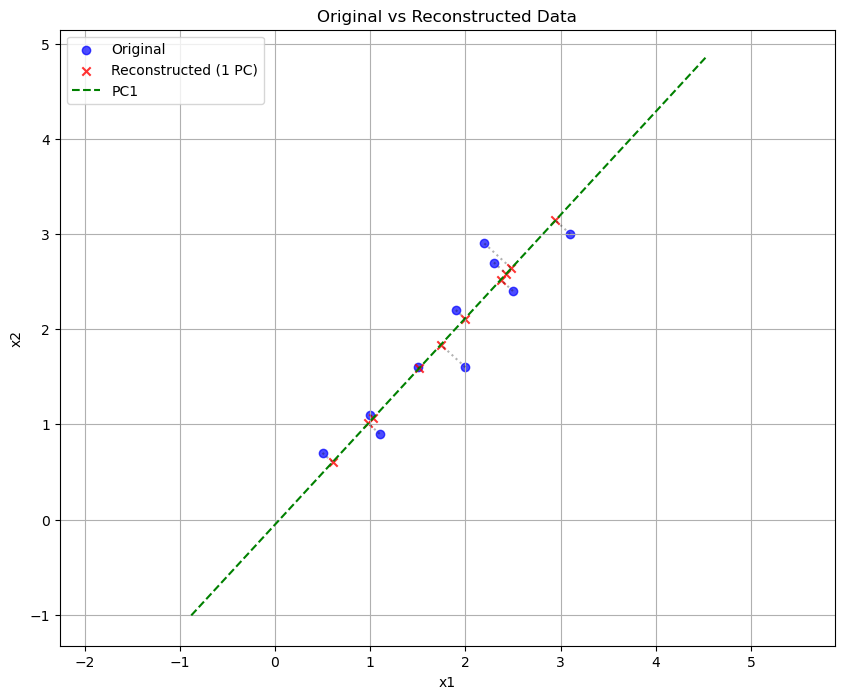

In [ ]:
# Visualization
mse = np.mean((X - X_reconstructed_partial)**2)
print(f"Reconstruction Error (MSE): {mse:.6f}\n")

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7, label='Original', c='blue', marker='o')
plt.scatter(X_reconstructed_partial[:, 0], X_reconstructed_partial[:, 1], alpha=0.8, label='Reconstructed (1 PC)', c='red', marker='x')

# Plot PC1 line
pc1_line = np.array([-V[:, 0], V[:, 0]]) * 4
plt.plot(mean[0] + pc1_line[:, 0], mean[1] + pc1_line[:, 1], 'g--', label='PC1')

# Connect points
for i in range(X.shape[0]):
    plt.plot([X[i, 0], X_reconstructed_partial[i, 0]], [X[i, 1], X_reconstructed_partial[i, 1]], 'k:', alpha=0.3)

plt.title('Original vs Reconstructed Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()